# Visualización encoders

En este notebook se visualizarán encoders MAE junto con las clases del challenge. La idea es ver si el encoder está logrando representar la próstata de una manera que se puedan separar de si tienen cáncer o no.
Para esto se visualizará tanto con PCa como también con KNN y así ver si las más cercanas efectivamente corresponden a ejemplos con cáncer o no respectivamente.

## Setup 

Primero que nada elegir el environment picai, así esta todo.

In [1]:
! ls

11292_1001315.nii.gz  LICENSE	 scripts	 test_grid.npy
configs		      main.py	 test_grid2.npy  test.ipynb
lib		      README.md  test_grid3.npy  visualize_encoder.ipynb


In [1]:
! nvidia-smi

Thu Sep 21 23:31:40 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 455.45.01    Driver Version: 455.45.01    CUDA Version: 11.1     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  GeForce RTX 208...  On   | 00000000:17:00.0 Off |                  N/A |
| 64%   66C    P0    96W / 260W |      3MiB / 11019MiB |      9%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  GeForce RTX 3090    On   | 00000000:65:00.0 Off |                  N/A |
| 74%   

In [2]:
import sys
import torch
import numpy as np
sys.path.append('lib/')
import lib.trainers as trainers # Esto importará el trainer de UNETR3D
                                # que cargará los pesos del modelo y dataloader

from lib.utils import get_conf
from sklearn.decomposition import PCA
from omegaconf import OmegaConf
import matplotlib.pyplot as plt

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_baseline



Please cite the following paper when using Report Guided Annotations:

Bosma, J.S., et al. "Semi-supervised learning with report-guided lesion annotation for deep learning-based prostate cancer detection in bpMRI" to be submitted


If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/Report-Guided-Annotation

If you have questions or suggestions, feel free to open an issue at https://github.com/DIAGNijmegen/picai_eval



Todo lo del trainer se maneja con un archivo de configuración. En este caso utilizaremos la config para segmentar próstata.

In [20]:
args = OmegaConf.load('configs/unetr_prostate_jupyter.yaml')
args.test = False

El trainer inicializa tanto el modelo con sus pesos como también el dataloader. Aunque no vayamos a entrenar podemos usarlo para correr algunos ejemplos y visualizarlos

In [21]:
trainer_name = 'SegTrainer'
trainer_class = getattr(trainers, trainer_name, None)


In [22]:
trainer = trainer_class(args)

In [23]:
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader/ckpts/checkpoint_0299.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder_pos_embed', 'mask_token', 'decoder.blocks.0.norm1.weight', 'decoder.blocks.0.norm1.bias', 'decoder.blocks.0.attn.qkv.weight', 'decoder.blocks.0.attn.qkv.bias', 'decoder.blocks.0.attn.proj.weight', 'decoder.blocks.0.attn.proj.bias', 'decoder.blocks.0.norm2.weight', 'decoder.blocks.0.norm2.bias', 'decoder.blocks.0.mlp.fc1.weight', 'decoder.blocks.0.mlp.fc1.bias', 'decoder.blocks.0.mlp.fc2.weight', 'decoder.blocks.0.mlp.fc2.bias', 'decoder.blocks.1.norm1.weight', 'decoder.blocks.1.norm1.bias', 'decoder.blocks.1.attn.qkv.weight', 'decoder.blocks.1.attn.qkv.bias', 'decoder.blocks.1.attn.proj.weight', 'decoder.blocks.1.attn.proj.bias', 'decoder.blocks.1.norm2.weight', 'decoder.blocks.1.norm2.bias', 'decoder.blocks.1.mlp.fc1.weight', 'd

/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:111: FutureWarning: <class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
  warn_deprecated(obj, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Ar

Nos interesa visualizar principalmente lo de encoder, asi que probemos obtener el embedding de un ejemplo.

In [24]:
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
encoder = trainer.wrapped_model.encoder


In [11]:
encoder.eval() # Pasamos a modo evaluacion
for i, batch_data in enumerate(dataloader):
    try:
        image = batch_data['data'].to(args.gpu, non_blocking=True)
        target = batch_data['seg'].to(args.gpu, non_blocking=True)
    except Exception:
        image = torch.from_numpy(batch_data['data']).to(args.gpu, non_blocking=True)
        target = torch.from_numpy(batch_data['seg']).to(args.gpu, non_blocking=True)
    print(image.shape, target.shape)
    output = encoder(image)
    print(output[0].shape)
    break

torch.Size([1, 3, 32, 256, 256]) torch.Size([1, 1, 32, 256, 256])
torch.Size([1, 512, 768])


Como se puede ver el output final del encoder es de 2 x 512 x 768. El 2 es por el batch size (2), 512 es por las dimensiones de la imagen y del patch size (32, 256, 256) y (16, 16, 16), los cuales se dividen por dimension y luego se multiplican -> 32/16 = 2, 256/16 = 16, 256/16 = 16 , resultando 2 * 16 * 16 = 512. Finalmente el 768 es el tamaño del embedding (este parámetro se decide simplemente)

De esta manera, el output se puede leer como que se crearon 512 patches de 16x16x16 los cuales fueron representados cada uno con un embedding de dimensión 768.

Primero visualicemos el output del encoder utilizando PCa. Lo que haremos será redimensionar nuestro output para que cada imágen esté representada por un tensor de 512x768. Estos tensores los juntaremos en una matriz de [n_samples, 512x768]. Luego utilizando PCa mantendremos 2 componentes, los cuales utilizaremos para realizar la visualización

In [25]:
pca = PCA(n_components=2)


In [27]:
def get_predicts_and_colors(enc, dataloader):

    enc.eval() # Pasamos a modo evaluacion
    predicts_list = []
    colors_list = []
    for batch_data in dataloader:
        try:
            image = batch_data['data'].to(args.gpu, non_blocking=True)
            target = batch_data['seg'].to(args.gpu, non_blocking=True)
        except Exception:
            image = torch.from_numpy(batch_data['data']).to(args.gpu, non_blocking=True)
            target = torch.from_numpy(batch_data['seg']).to(args.gpu, non_blocking=True)
        output = enc(image)
        # El output del modelo devuelve (x_final, hidden_steps). En este caso nos interesa ver el final
        img_1 = output[0].reshape((-1)).cpu().detach().numpy()
        predicts_list.append(img_1)
        if target.max() > 0:
            colors_list.append('red')
        else:
            colors_list.append('blue')
        
    predict_array = np.vstack(predicts_list)
    return predict_array, colors_list

In [28]:
predict_array, colors_list = get_predicts_and_colors(encoder, dataloader)

In [15]:
len(predict_array)

298

In [29]:
transformed = pca.fit_transform(predict_array)

In [30]:
transformed.shape

(300, 2)

In [31]:
len(colors_list)

300

### Visualizacion checkpoint mae3d_sincos_vit_base_prostate_picai_dataloader mask 0.125
Visualicemos con matplotlib. Los rojos tienen cancer y los azules no

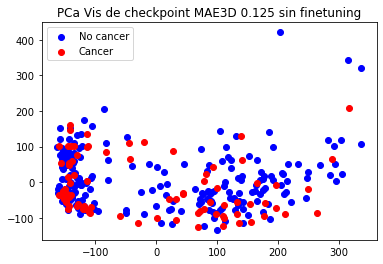

In [32]:
color_arr = np.array(colors_list)
plt.scatter(transformed[np.where(color_arr=='blue'),0], transformed[np.where(color_arr=='blue'),1], c='blue', label="No cancer")
plt.scatter(transformed[np.where(color_arr=='red'),0], transformed[np.where(color_arr=='red'),1], c='red', label="Cancer")
plt.title("PCa Vis de checkpoint MAE3D 0.125 sin finetuning")
plt.legend()
plt.show()

### Visualizacion checkpoint unetr3d_vit_base_prostate16_picai_dataloader_picai_no_pretrain best model

In [34]:
# Cambiamos el checkpoint
args.resume = '/mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_no_pretrain/ckpts/best_model.pth.tar'
trainer = trainer_class(args)
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()
trainer.resume()
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
encoder = trainer.wrapped_model.encoder

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader/ckpts/checkpoint_0299.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder_pos_embed', 'mask_token', 'decoder.blocks.0.norm1.weight', 'decoder.blocks.0.norm1.bias', 'decoder.blocks.0.attn.qkv.weight', 'decoder.blocks.0.attn.qkv.bias', 'decoder.blocks.0.attn.proj.weight', 'decoder.blocks.0.attn.proj.bias', 'decoder.blocks.0.norm2.weight', 'decoder.blocks.0.norm2.bias', 'decoder.blocks.0.mlp.fc1.weight', 'decoder.blocks.0.mlp.fc1.bias', 'decoder.blocks.0.mlp.fc2.weight', 'decoder.blocks.0.mlp.fc2.bias', 'decoder.blocks.1.norm1.weight', 'decoder.blocks.1.norm1.bias', 'decoder.blocks.1.attn.qkv.weight', 'decoder.blocks.1.attn.qkv.bias', 'decoder.blocks.1.attn.proj.weight', 'decoder.blocks.1.attn.proj.bias', 'decoder.blocks.1.norm2.weight', 'decoder.blocks.1.norm2.bias', 'decoder.blocks.1.mlp.fc1.weight', 'd

/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:111: FutureWarning: <class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
  warn_deprecated(obj, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Ar

=> loaded checkpoint '/mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_no_pretrain/ckpts/best_model.pth.tar' (epoch 310)


In [35]:
predict_array, colors_list = get_predicts_and_colors(encoder, dataloader)
pca = PCA(n_components=2)
transformed = pca.fit_transform(predict_array)

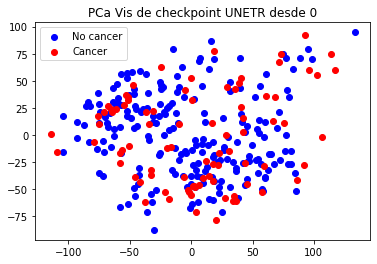

In [36]:
color_arr = np.array(colors_list)
plt.scatter(transformed[np.where(color_arr=='blue'),0], transformed[np.where(color_arr=='blue'),1], c='blue', label="No cancer")
plt.scatter(transformed[np.where(color_arr=='red'),0], transformed[np.where(color_arr=='red'),1], c='red', label="Cancer")
plt.title("PCa Vis de checkpoint UNETR desde 0")
plt.legend()
plt.show()

### Visualizacion checkpoint unetr3d_vit_base_prostate16_picai_dataloader_picai_pretrain 0.125

In [29]:
# Cambiamos el checkpoint
args.pretrain = '/mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_pretrain/ckpts/best_model.pth.tar'
trainer = trainer_class(args)
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
encoder = trainer.wrapped_model.encoder

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_pretrain/ckpts/best_model.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder.encoder1.layer.conv1.conv.weight', 'decoder.encoder1.layer.conv2.conv.weight', 'decoder.encoder1.layer.conv3.conv.weight', 'decoder.encoder2.transp_conv_init.conv.weight', 'decoder.encoder2.blocks.0.0.conv.weight', 'decoder.encoder2.blocks.0.1.conv1.conv.weight', 'decoder.encoder2.blocks.0.1.conv2.conv.weight', 'decoder.encoder2.blocks.1.0.conv.weight', 'decoder.encoder2.blocks.1.1.conv1.conv.weight', 'decoder.encoder2.blocks.1.1.conv2.conv.weight', 'decoder.encoder3.transp_conv_init.conv.weight', 'decoder.encoder3.blocks.0.0.conv.weight', 'decoder.encoder3.blocks.0.1.conv1.conv.weight', 'decoder.encoder3.blocks.0.1.conv2.conv.weight', 'decoder.encoder4.transp_conv_init.conv.weight', 'decoder.decoder5.transp_conv.conv.weig

/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:111: FutureWarning: <class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
  warn_deprecated(obj, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Ar

In [30]:
predict_array, colors_list = get_predicts_and_colors(encoder, dataloader)
pca = PCA(n_components=2)
transformed = pca.fit_transform(predict_array)

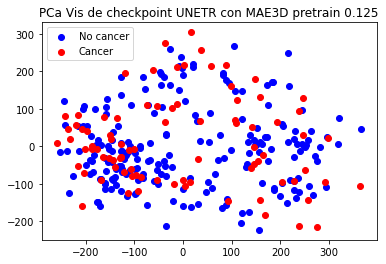

In [31]:
color_arr = np.array(colors_list)
plt.scatter(transformed[np.where(color_arr=='blue'),0], transformed[np.where(color_arr=='blue'),1], c='blue', label="No cancer")
plt.scatter(transformed[np.where(color_arr=='red'),0], transformed[np.where(color_arr=='red'),1], c='red', label="Cancer")
plt.title("PCa Vis de checkpoint UNETR con MAE3D pretrain 0.125")
plt.legend()
plt.show()

### Visualizacion checkpoint mae3d_sincos_vit_base_prostate_picai_dataloader_only_negative

In [33]:
# Cambiamos el checkpoint
args.pretrain = '/mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader_only_negative/ckpts/checkpoint_0299.pth.tar'
trainer = trainer_class(args)
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
encoder = trainer.wrapped_model.encoder
predict_array, colors_list = get_predicts_and_colors(encoder, dataloader)
pca = PCA(n_components=2)
transformed = pca.fit_transform(predict_array)
color_arr = np.array(colors_list)

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader_only_negative/ckpts/checkpoint_0299.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder_pos_embed', 'mask_token', 'decoder.blocks.0.norm1.weight', 'decoder.blocks.0.norm1.bias', 'decoder.blocks.0.attn.qkv.weight', 'decoder.blocks.0.attn.qkv.bias', 'decoder.blocks.0.attn.proj.weight', 'decoder.blocks.0.attn.proj.bias', 'decoder.blocks.0.norm2.weight', 'decoder.blocks.0.norm2.bias', 'decoder.blocks.0.mlp.fc1.weight', 'decoder.blocks.0.mlp.fc1.bias', 'decoder.blocks.0.mlp.fc2.weight', 'decoder.blocks.0.mlp.fc2.bias', 'decoder.blocks.1.norm1.weight', 'decoder.blocks.1.norm1.bias', 'decoder.blocks.1.attn.qkv.weight', 'decoder.blocks.1.attn.qkv.bias', 'decoder.blocks.1.attn.proj.weight', 'decoder.blocks.1.attn.proj.bias', 'decoder.blocks.1.norm2.weight', 'decoder.blocks.1.norm2.bias', 'decoder.blocks.1.mlp.f

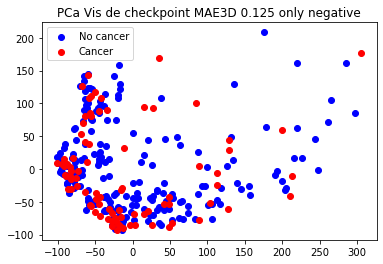

In [34]:
plt.scatter(transformed[np.where(color_arr=='blue'),0], transformed[np.where(color_arr=='blue'),1], c='blue', label="No cancer")
plt.scatter(transformed[np.where(color_arr=='red'),0], transformed[np.where(color_arr=='red'),1], c='red', label="Cancer")
plt.title("PCa Vis de checkpoint MAE3D 0.125 only negative")
plt.legend()
plt.show()

Visualización mae3d_sincos_vit_base_prostate_picai_dataloader_mask0.5

In [35]:
# Cambiamos el checkpoint
args.pretrain = '/mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader_mask0.5/ckpts/checkpoint_0299.pth.tar'
trainer = trainer_class(args)
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
encoder = trainer.wrapped_model.encoder
predict_array, colors_list = get_predicts_and_colors(encoder, dataloader)
pca = PCA(n_components=2)
transformed = pca.fit_transform(predict_array)
color_arr = np.array(colors_list)

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader_mask0.5/ckpts/checkpoint_0299.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder_pos_embed', 'mask_token', 'decoder.blocks.0.norm1.weight', 'decoder.blocks.0.norm1.bias', 'decoder.blocks.0.attn.qkv.weight', 'decoder.blocks.0.attn.qkv.bias', 'decoder.blocks.0.attn.proj.weight', 'decoder.blocks.0.attn.proj.bias', 'decoder.blocks.0.norm2.weight', 'decoder.blocks.0.norm2.bias', 'decoder.blocks.0.mlp.fc1.weight', 'decoder.blocks.0.mlp.fc1.bias', 'decoder.blocks.0.mlp.fc2.weight', 'decoder.blocks.0.mlp.fc2.bias', 'decoder.blocks.1.norm1.weight', 'decoder.blocks.1.norm1.bias', 'decoder.blocks.1.attn.qkv.weight', 'decoder.blocks.1.attn.qkv.bias', 'decoder.blocks.1.attn.proj.weight', 'decoder.blocks.1.attn.proj.bias', 'decoder.blocks.1.norm2.weight', 'decoder.blocks.1.norm2.bias', 'decoder.blocks.1.mlp.fc1.wei

/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:111: FutureWarning: <class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
  warn_deprecated(obj, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Ar

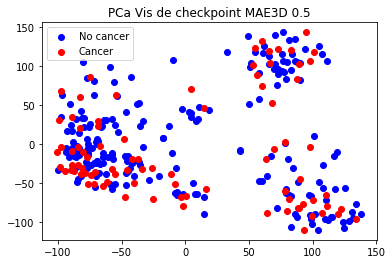

In [37]:
plt.scatter(transformed[np.where(color_arr=='blue'),0], transformed[np.where(color_arr=='blue'),1], c='blue', label="No cancer")
plt.scatter(transformed[np.where(color_arr=='red'),0], transformed[np.where(color_arr=='red'),1], c='red', label="Cancer")
plt.title("PCa Vis de checkpoint MAE3D 0.5")
plt.legend()
plt.show()

# Visualización outputs del segmentador

Para correr esta parte hacer los imports e inicializar el trainer

In [47]:
args.resume = '/mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_pretrain/ckpts/best_model.pth.tar'
trainer = trainer_class(args)
trainer.build_model()
# create optimizer
trainer.build_optimizer()
# resume training
trainer.build_dataloader()
trainer.resume()
dataloader = trainer.val_dataloader # Usamos el dataloader de validacion
model = trainer.wrapped_model

=> creating model UNETR3D
=> Start loading pretrained weights from /mnt/workspace/jfacuse/test_MedMAE/mae3d_sincos_vit_base_prostate_picai_dataloader/ckpts/checkpoint_0299.pth.tar
Loading messages: 
 _IncompatibleKeys(missing_keys=[], unexpected_keys=['decoder_pos_embed', 'mask_token', 'decoder.blocks.0.norm1.weight', 'decoder.blocks.0.norm1.bias', 'decoder.blocks.0.attn.qkv.weight', 'decoder.blocks.0.attn.qkv.bias', 'decoder.blocks.0.attn.proj.weight', 'decoder.blocks.0.attn.proj.bias', 'decoder.blocks.0.norm2.weight', 'decoder.blocks.0.norm2.bias', 'decoder.blocks.0.mlp.fc1.weight', 'decoder.blocks.0.mlp.fc1.bias', 'decoder.blocks.0.mlp.fc2.weight', 'decoder.blocks.0.mlp.fc2.bias', 'decoder.blocks.1.norm1.weight', 'decoder.blocks.1.norm1.bias', 'decoder.blocks.1.attn.qkv.weight', 'decoder.blocks.1.attn.qkv.bias', 'decoder.blocks.1.attn.proj.weight', 'decoder.blocks.1.attn.proj.bias', 'decoder.blocks.1.norm2.weight', 'decoder.blocks.1.norm2.bias', 'decoder.blocks.1.mlp.fc1.weight', 'd

/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.io.dictionary LoadImaged.__init__:image_only: Current default value of argument `image_only=False` has been deprecated since version 1.1. It will be changed to `image_only=True` in version 1.3.
  warn_deprecated(argname, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:111: FutureWarning: <class 'monai.transforms.utility.dictionary.AddChanneld'>: Class `AddChanneld` has been deprecated since version 0.8. It will be removed in version 1.3. please use MetaTensor data type and monai.transforms.EnsureChannelFirstd instead with `channel_dim='no_channel'`.
  warn_deprecated(obj, msg, warning_category)
/home/jfacuse/miniconda3/envs/picai/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.transforms.utility.dictionary EnsureChannelFirstd.__init__:meta_keys: Ar

=> loaded checkpoint '/mnt/workspace/jfacuse/test_MedMAE/unetr3d_vit_base_prostate16_picai_dataloader_picai_pretrain/ckpts/best_model.pth.tar' (epoch 410)


In [48]:
from monai.data import decollate_batch
from monai.inferers import sliding_window_inference

In [86]:
roi_size = (args.roi_x, args.roi_y, args.roi_z)
all_valid_preds, all_valid_labels = [], []
for i, batch_data in enumerate(dataloader):
    try:
        image = batch_data['data'].to(args.gpu, non_blocking=True)
        target = batch_data['seg'].to(args.gpu, non_blocking=True)
    except Exception:
        image = torch.from_numpy(batch_data['data']).to(args.gpu, non_blocking=True)
        target = torch.from_numpy(batch_data['seg']).to(args.gpu, non_blocking=True)
    if torch.max(target) == 0:
          continue
    with torch.cuda.amp.autocast():
                output = sliding_window_inference(image,
                                                  roi_size=roi_size,
                                                  sw_batch_size=4,
                                                  predictor=model,
                                                  overlap=args.infer_overlap)
    target_convert = torch.stack([trainer.post_label(target_tensor) for target_tensor in decollate_batch(target)], dim=0)
    output_convert = torch.stack([trainer.post_pred(output_tensor) for output_tensor in decollate_batch(output)], dim=0)
    perm_pred = output_convert[:, 1, ...]
    perm_target = target_convert[:, 0, ...]
    all_valid_preds += [perm_pred.detach().cpu().numpy()]
    all_valid_labels += [perm_target.detach().cpu().numpy()]
    break
final_pred = np.concatenate([x for x in np.array(all_valid_preds)], axis=0)
final_label = np.concatenate([x for x in np.array(all_valid_labels)], axis=0)

In [40]:
from report_guided_annotation import extract_lesion_candidates

In [51]:
extracted = extract_lesion_candidates(final_pred[0])

In [87]:
from picai_eval import evaluate
valid_metrics = evaluate(y_det=iter(final_pred),
                             y_true=iter(final_label),
                             y_det_postprocess_func=lambda pred: extract_lesion_candidates(pred)[0])



In [58]:
valid_metrics.lesion_results

{0: [(0, 0.37399014830589294, 0.0),
  (0, 0.2933032512664795, 0.0),
  (0, 0.5518152117729187, 0.0),
  (0, 0.24707795679569244, 0.0),
  (0, 0.2557152211666107, 0.0),
  (0, 0.2989005148410797, 0.0),
  (0, 0.3879801034927368, 0.0),
  (0, 0.3147873282432556, 0.0),
  (0, 0.24725967645645142, 0.0),
  (0, 0.4816519320011139, 0.0),
  (0, 0.25945019721984863, 0.0)],
 1: [(0, 0.3268083333969116, 0.0),
  (0, 0.2711551785469055, 0.0),
  (0, 0.31573596596717834, 0.0),
  (0, 0.23792988061904907, 0.0),
  (0, 0.29037681221961975, 0.0),
  (0, 0.15869519114494324, 0.0),
  (0, 0.20561504364013672, 0.0),
  (0, 0.21502088010311127, 0.0),
  (0, 0.15974101424217224, 0.0)],
 2: [(0, 0.376852422952652, 0.0), (0, 0.18997150659561157, 0.0)],
 3: [(0, 0.4727290868759155, 0.0),
  (0, 0.2278127372264862, 0.0),
  (0, 0.4596218466758728, 0.0),
  (0, 0.224735289812088, 0.0)],
 4: [(0, 0.4735202491283417, 0.0),
  (0, 0.2791401743888855, 0.0),
  (0, 0.2994123697280884, 0.0),
  (0, 0.291989266872406, 0.0),
  (0, 0.330687

In [59]:
all_valid_preds[10]

array([[[[0.02832831, 0.01791734, 0.00891613, ..., 0.00766587,
          0.02100437, 0.02556521],
         [0.01894171, 0.00793799, 0.00348342, ..., 0.0029464 ,
          0.00912564, 0.01513073],
         [0.00874518, 0.00346989, 0.00191177, ..., 0.00190433,
          0.00373622, 0.00720477],
         ...,
         [0.01111501, 0.00411792, 0.00290086, ..., 0.00252127,
          0.00530189, 0.0102883 ],
         [0.01912403, 0.01020905, 0.00473675, ..., 0.004086  ,
          0.01252793, 0.01840489],
         [0.03283696, 0.0186178 , 0.01098694, ..., 0.00959645,
          0.02288984, 0.03015741]],

        [[0.02947941, 0.01518905, 0.0071491 , ..., 0.00666693,
          0.01704532, 0.02590802],
         [0.0123361 , 0.00468182, 0.00189692, ..., 0.00175461,
          0.00549056, 0.01224128],
         [0.00641316, 0.00188219, 0.0011514 , ..., 0.0012208 ,
          0.00201116, 0.00530189],
         ...,
         [0.0071491 , 0.00263167, 0.00181021, ..., 0.00157926,
          0.00298103, 0.0

In [61]:
all_valid_labels[10]

1

In [62]:
valid_metrics.thresholds

In [63]:
from picai_eval import evaluate
valid_metrics_dynamic = evaluate(y_det=iter(final_pred),
                             y_true=iter(final_label),
                             y_det_postprocess_func=lambda pred: extract_lesion_candidates(pred, threshold='dynamic')[0])

In [75]:
from picai_eval import evaluate
valid_metrics_50 = evaluate(y_det=iter(final_pred),
                             y_true=iter(final_label),
                             y_det_postprocess_func=lambda pred: extract_lesion_candidates(pred, threshold=0.1)[0])

In [64]:
valid_metrics_dynamic

Metrics(auroc=74.72%, AP=35.29%, 300 cases, 90 lesions)

In [65]:
valid_metrics

Metrics(auroc=74.72%, AP=35.34%, 300 cases, 90 lesions)

In [76]:
valid_metrics_50

Metrics(auroc=74.72%, AP=31.29%, 300 cases, 90 lesions)

In [97]:
extracted = extract_lesion_candidates(all_valid_preds[0][0])
label = all_valid_labels[0][0]

In [90]:
extracted


(array([[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]],
 
        ...,
 
        [[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],


In [91]:
label

array([[[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        ...,

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
    

In [88]:
valid_metrics.lesion_results

{0: [(1, 0.5754090547561646, 0.4231645072639001),
  (0, 0.29057806730270386, 0.0),
  (0, 0.291989266872406, 0.0)]}

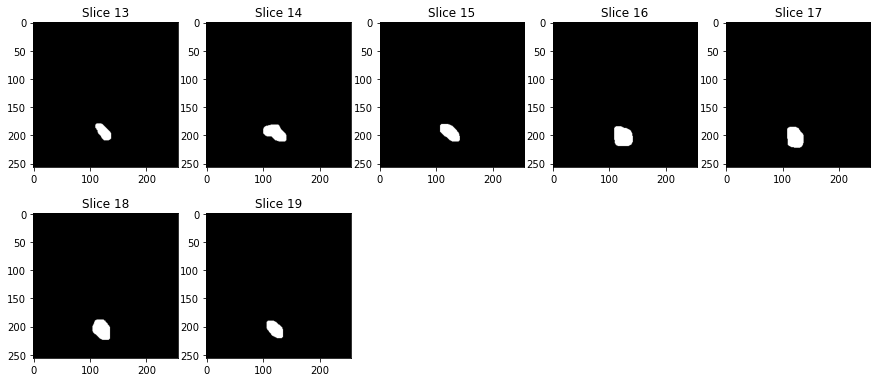

In [117]:
plt.figure(figsize=(15,17))
count = 1
for i,s in enumerate(label):
    if np.max(s) > 0:
        plt.subplot(5,5,count)
        plt.imshow(s, cmap='gray')
        plt.title(f'Slice {str(i)}')
        count +=1

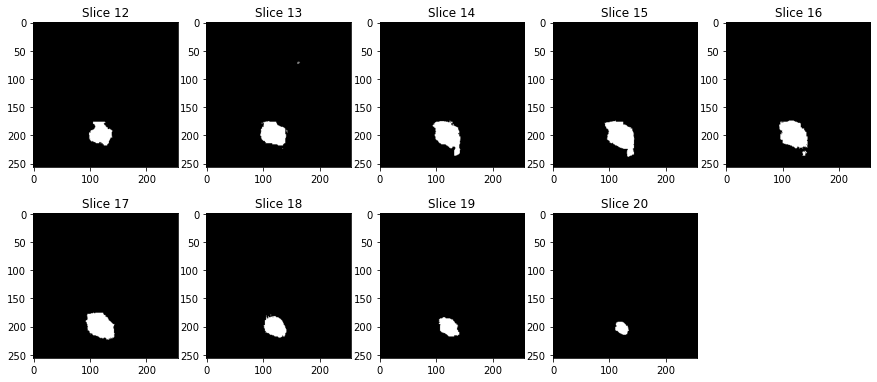

In [118]:
plt.figure(figsize=(15,17))
count = 1
for i,s in enumerate(extracted[0]):
    if np.max(s) > 0:
        plt.subplot(5,5,count)
        plt.imshow(s, cmap='gray')
        plt.title(f'Slice {str(i)}')
        count +=1

In [109]:
batch_data['data'].shape

(1, 3, 32, 256, 256)

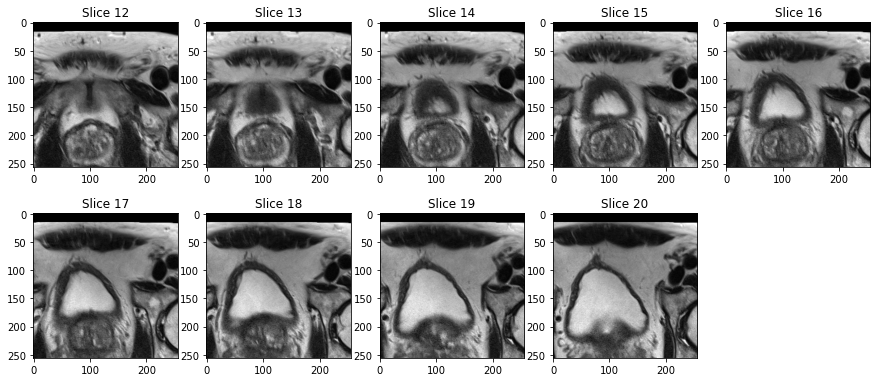

In [119]:
plt.figure(figsize=(15,17))
count = 1
for i,s in enumerate(extracted[0]):
    if np.max(s) > 0:
        plt.subplot(5,5,count)
        plt.imshow(batch_data['data'][0][0][i], cmap='gray')
        plt.title(f'Slice {str(i)}')
        count +=1

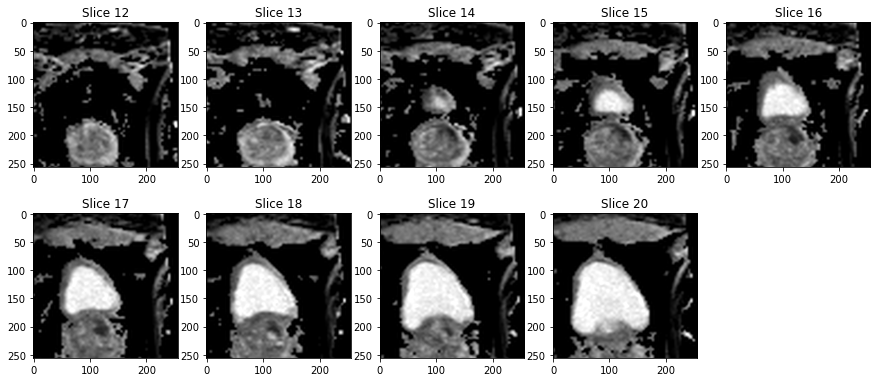

In [116]:
plt.figure(figsize=(15,17))
count = 1
for i,s in enumerate(extracted[0]):
    if np.max(s) > 0:
        plt.subplot(5,5,count)
        plt.imshow(batch_data['data'][0][1][i], cmap='gray')
        plt.title(f'Slice {str(i)}')
        count +=1

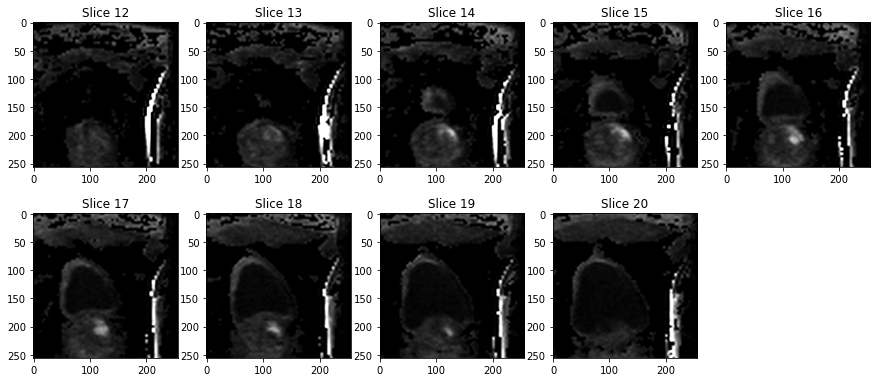

In [115]:
plt.figure(figsize=(15,17))
count = 1
for i,s in enumerate(extracted[0]):
    if np.max(s) > 0:
        plt.subplot(5,5,count)
        plt.imshow(batch_data['data'][0][2][i], cmap='gray')
        plt.title(f'Slice {str(i)}')
        count +=1